In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
diabetes=load_diabetes()
X=pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y=pd.Series(diabetes.target)
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
ridge=Ridge(alpha=0.1)
lasso=Lasso(alpha=0.1)
elastic=ElasticNet(alpha=0.1, l1_ratio=0.5)

In [6]:
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
elastic.fit(X_train, y_train)

,alpha,0.1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [7]:
y_pred_lasso=lasso.predict(X_test)
print(f"Lasso R2 Score: {r2_score(y_test, y_pred_lasso):.4f}")
print(f"Lasso RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.2f}")

Lasso R2 Score: 0.4719
Lasso RMSE: 52.90


In [8]:
y_pred_ridge=ridge.fit(X_train, y_train).predict(X_test)
y_pred_elastic=elastic.fit(X_train, y_train).predict(X_test)

print(f"Lasso Regression       -> R2: {0.4719} | RMSE: {52.90}")
print(f"Ridge Regression       -> R2: {r2_score(y_test, y_pred_ridge):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.2f}")
print(f"Elastic Net Regression -> R2: {r2_score(y_test, y_pred_elastic):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_elastic)):.2f}")

Lasso Regression       -> R2: 0.4719 | RMSE: 52.9
Ridge Regression       -> R2: 0.4609 | RMSE: 53.45
Elastic Net Regression -> R2: 0.0987 | RMSE: 69.10


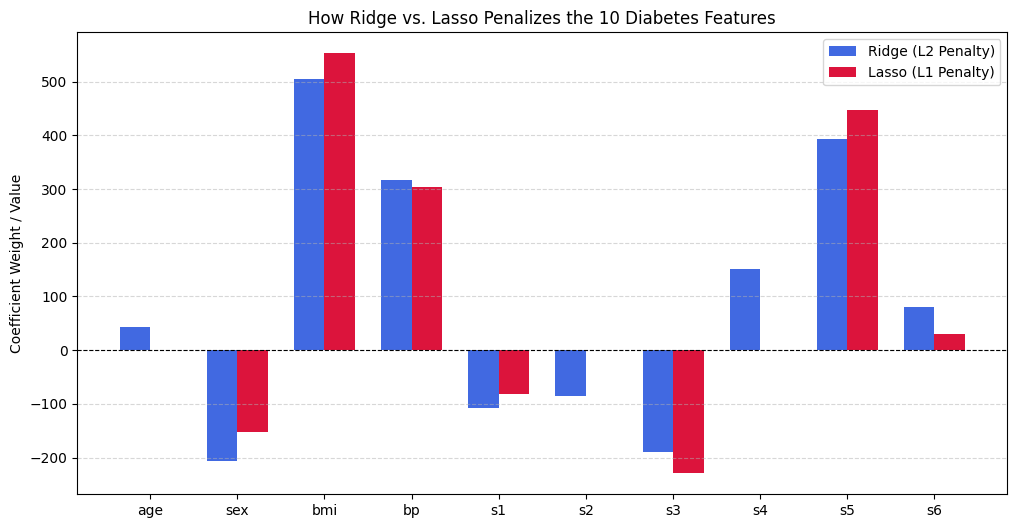

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame to hold all coefficients for easy plotting
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Ridge (L2)': ridge.coef_,
    'Lasso (L1)': lasso.coef_
})

# Set up a side-by-side bar plot layout
x = np.arange(len(coef_df['Feature']))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, coef_df['Ridge (L2)'], width, label='Ridge (L2 Penalty)', color='royalblue')
rects2 = ax.bar(x + width/2, coef_df['Lasso (L1)'], width, label='Lasso (L1 Penalty)', color='crimson')

# Add clean visual configurations
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Coefficient Weight / Value')
ax.set_title('How Ridge vs. Lasso Penalizes the 10 Diabetes Features')
ax.set_xticks(x)
ax.set_xticklabels(coef_df['Feature'])
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


### Regularization Performance Analysis

| Model Architecture | Penalty Type | $R^2$ Score (Variance Explained) | Root Mean Squared Error (RMSE) |
| :--- | :--- | :--- | :--- |
| **Multiple Linear Regression** | None (Baseline) | 45.26% | 53.85 units |
| **Lasso Regression** | L1 (Feature Selection) | **47.19%** | **52.90 units** |
| **Ridge Regression** | L2 (Weight Shrinkage) | 46.09% | 53.45 units |
| **Elastic Net** | Hybrid (L1 + L2 Mix) | 9.87% | 69.10 units |

#### Key Takeaways:
1. **Lasso Optimization:** Lasso achieved our best performance yet, dropping the RMSE to 52.90. By forcing weaker feature coefficients directly to zero, it successfully eliminated multi-collinearity among the blood serum (`s1`-`s6`) measurements.
2. **The Elastic Net Drop:** The dramatic performance drop in Elastic Net (9.87%) is a text-book example of **over-regularization (underfitting)**. Applying both penalties simultaneously with default hyperparameters choked the weights too heavily. 
